# Interval unfolding with posterior analysis (`unfold_interval_posterior`)

This notebook applies the interval unfolding method with posterior
interval analysis to the IAEA Compendium benchmark spectrum:

> Yu. V. Matiyasevich, *A posteriori interval analysis*, Lecture Notes
> in Computer Science, vol. 204, pp. 328-334, 1985.

The method computes guaranteed bounds on the neutron spectrum using
the traditional LP approach, then refines the intervals using
posterior analysis (Matiyasevich's method) for tighter bounds.
The sensitivity vector and residuals are computed to assess the
quality of the solution.

This approach provides additional diagnostic information beyond the
basic interval LP method, including per-bin sensitivity to input
uncertainties and residual analysis.


In [1]:
# %pip install bssunfold pandas numpy matplotlib

## 1. Detector response functions

We use the built-in GSF response functions (10 Bonner spheres, `0in` -
`18in`, 60 energy bins from 1e-9 to ~631 MeV).


Detector grid: 60 bins, 1.0e-09 - 631.0 MeV
Spheres: 0in, 2in, 3in, 5in, 6in, 8in, 10in, 12in, 15in, 18in


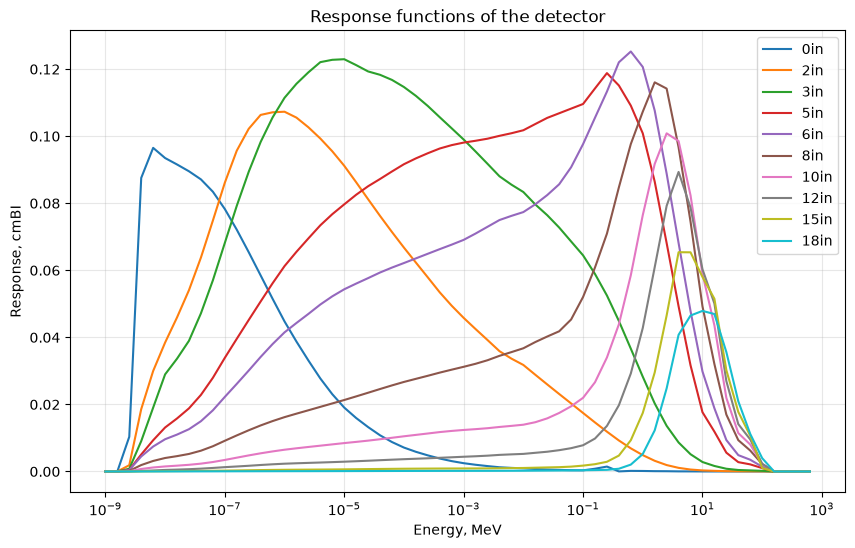

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bssunfold import Detector, RF_GSF
from bssunfold.utils.comparison import compare_spectra

detector = Detector(RF_GSF)
E = detector.E_MeV
names = detector.detector_names
print(f"Detector grid: {detector.n_energy_bins} bins, "
      f"{E[0]:.1e} - {E[-1]:.1f} MeV")
print("Spheres:", ", ".join(names))
detector.plot_response_functions()

## 2. IAEA Compendium reference spectrum -> detector readings

The compendium CSV stores 61-point Monte-Carlo spectra on its own energy
grid, which differs slightly from the 60-bin detector grid, so the
ground truth is interpolated onto the detector grid *for evaluation
only*.  The readings are the spectrum folded with the response
functions.


In [3]:
reference_csv = pd.read_csv(
    '../tests/MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv'
)
print(f"Reference CSV: {len(reference_csv)} rows, "
      f"{len(reference_csv.columns) - 1} spectra, "
      f"{reference_csv['E_MeV'].min():.1e} - "
      f"{reference_csv['E_MeV'].max():.0f} MeV")

SPECTRUM = 't4-14-s.txt_1'   # IAEA Compendium BSA benchmark case

readings = detector.get_effective_readings_for_spectra(
    reference_csv[['E_MeV', SPECTRUM]]
)
print("Effective readings:")
for name, val in readings.items():
    print(f"  {name:>4s}: {val:.4f}")

# Interpolate ground truth onto detector grid for evaluation
phi_true = np.interp(
    E, reference_csv['E_MeV'], reference_csv[SPECTRUM]
)

# Active energy bins for plotting
Emax = 20.0
active = E <= Emax
E_active = E[active]
phi_true_active = phi_true[active]


Reference CSV: 61 rows, 20 spectra, 1.0e-09 - 631 MeV
Effective readings:
   0in: 0.0668
   2in: 0.0901
   3in: 0.1382
   5in: 0.1639
   6in: 0.1407
   8in: 0.0805
  10in: 0.0392
  12in: 0.0179
  15in: 0.0064
  18in: 0.0031


## 3. Unfold with posterior interval analysis

Two noise levels are demonstrated:

* **narrow interval** (`noise_level=0.05`) — 5% measurement uncertainty,
  tighter bounds on the spectrum;
* **wide interval** (`noise_level=0.20`) — 20% measurement uncertainty,
  wider bounds reflecting greater uncertainty.

The energy cutoff `max_neutron_energy=20.0` confines the solution to
the range covered by the benchmark spectrum.


In [4]:
result_narrow = detector.unfold_interval_posterior(
    readings,
    noise_level=0.05,
    max_neutron_energy=20.0,
    save_result=False,
)

result_wide = detector.unfold_interval_posterior(
    readings,
    noise_level=0.20,
    max_neutron_energy=20.0,
    save_result=False,
)

for label, result in [("narrow (5%)", result_narrow),
                      ("wide (20%)", result_wide)]:
    print(f"\n{label}:")
    print(f"  method        : {result['method']}")
    print(f"  n_samples     : {result['n_samples']}")
    print(f"  interval width: {np.sum(result['spectrum_upper'] - result['spectrum_lower']):.4f}")
    print(f"  max residual  : {np.max(np.abs(result['residuals'])):.4f}")


narrow (5%):
  method        : IntervalPosterior
  n_samples     : 100
  interval width: 46.4517
  max residual  : 1.5610

wide (20%):
  method        : IntervalPosterior
  n_samples     : 100
  interval width: 61.7980
  max residual  : 2.1584


## 4. Noise level sweep

The noise level controls the width of the interval constraints.
Smaller noise levels produce tighter bounds but may lead to empty
tolerance sets.  Larger noise levels give wider but more robust
intervals.


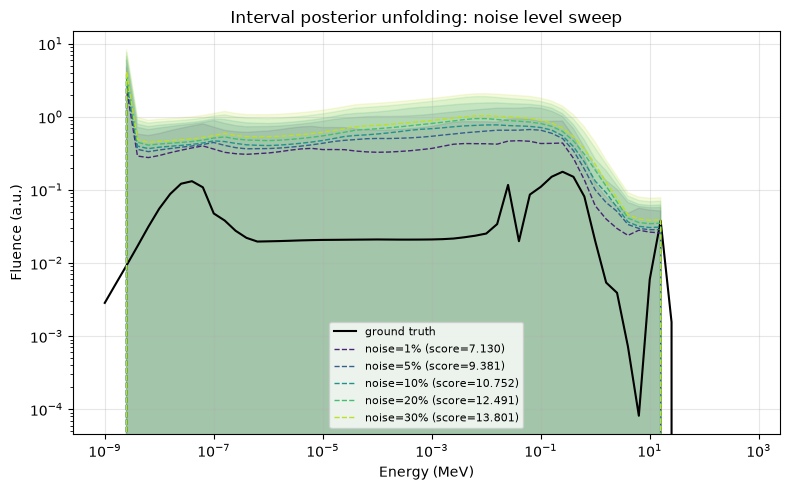

In [5]:
noise_levels = [0.01, 0.05, 0.10, 0.20, 0.30]

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(E, phi_true, "k-", lw=1.5, label="ground truth")
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(noise_levels)))
for color, nl in zip(colors, noise_levels):
    res = detector.unfold_interval_posterior(
        readings, noise_level=nl, max_neutron_energy=20.0, save_result=False,
    )
    m = compare_spectra(phi_true, res["spectrum"],
                        metrics=["comprehensive_score"])
    ax.loglog(E, res["spectrum"], "--", color=color, lw=1,
              label=f"noise={nl:.0%} (score={m['comprehensive_score']:.3f})")
    ax.fill_between(E, res["spectrum_lower"], res["spectrum_upper"],
                    color=color, alpha=0.15)

ax.set_xlabel("Energy (MeV)")
ax.set_ylabel("Fluence (a.u.)")
ax.set_title("Interval posterior unfolding: noise level sweep")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Emax = 20.0
active = E <= Emax
E_active = E[active]
phi_true_active = phi_true[active]

## 5. Sensitivity analysis

The posterior analysis computes a sensitivity vector that quantifies
how sensitive each energy bin is to input uncertainties.  Bins with
high sensitivity contribute more to the overall uncertainty.


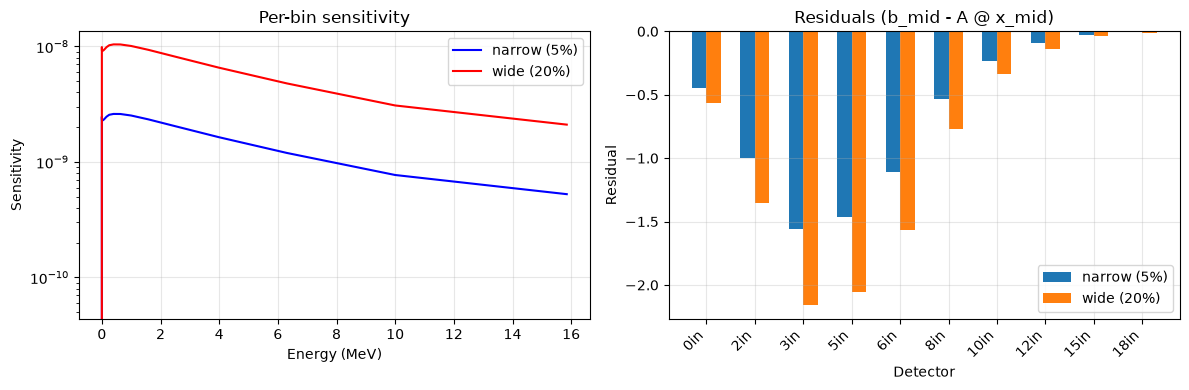

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(E_active, result_narrow["sensitivity"], "b-", label="narrow (5%)")
axes[0].semilogy(E_active, result_wide["sensitivity"], "r-", label="wide (20%)")
axes[0].set_xlabel("Energy (MeV)")
axes[0].set_ylabel("Sensitivity")
axes[0].set_title("Per-bin sensitivity")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

det_idx = np.arange(len(result_narrow["residuals"]))
det_names = list(readings.keys())
axes[1].bar(det_idx - 0.15, result_narrow["residuals"], 0.3, label="narrow (5%)")
axes[1].bar(det_idx + 0.15, result_wide["residuals"], 0.3, label="wide (20%)")
axes[1].set_xticks(det_idx)
axes[1].set_xticklabels(det_names, rotation=45, ha="right")
axes[1].set_xlabel("Detector")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals (b_mid - A @ x_mid)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Baselines

Two widely used iterative baselines — **GRAVEL** (weighted log-domain
least squares) and **MLEM** — start from the same flat prior for
comparison.


method                  score
------------------------------
Interval posterior      9.381
GRAVEL                  2.954
MLEM                    1.519


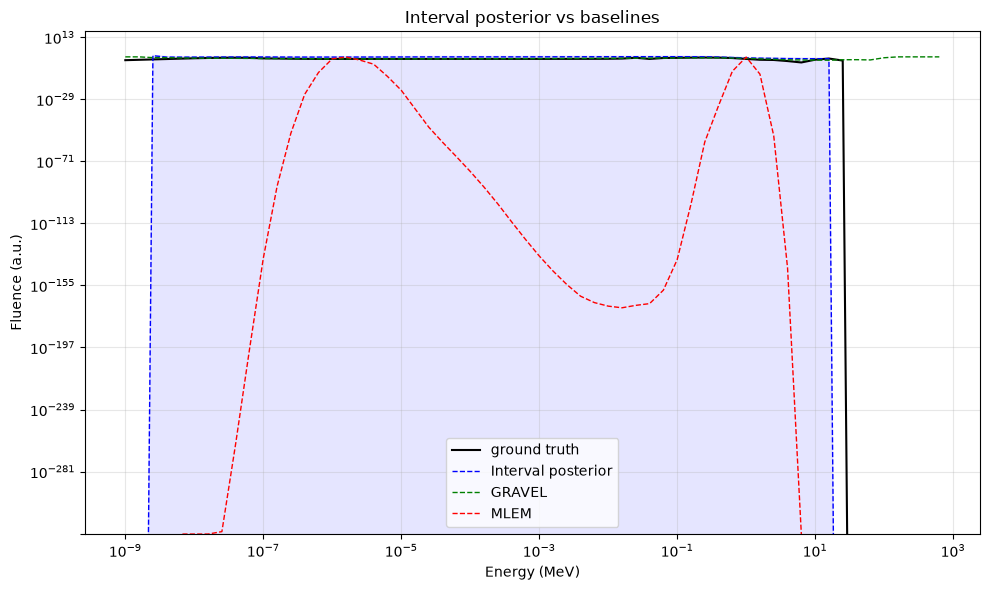

In [7]:
grav = detector.unfold_gravel(
    readings,
    initial_spectrum=np.full(E.size, 0.5),
    max_iterations=2000,
    save_result=False,
)
mlem = detector.unfold_mlem(
    readings,
    initial_spectrum=np.full(E.size, 0.5),
    max_iterations=2000,
    save_result=False,
)

labels = ["Interval posterior", "GRAVEL", "MLEM"]
spectra = [result_narrow["spectrum"], grav["spectrum"], mlem["spectrum"]]
print(f"{'method':<20s} {'score':>8s}")
print("-" * 30)
for label, spec in zip(labels, spectra):
    m = compare_spectra(phi_true, spec, metrics=["comprehensive_score"])
    print(f"{label:<20s} {m['comprehensive_score']:>8.3f}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(E, phi_true, "k-", lw=1.5, label="ground truth")
for label, spec, color in zip(labels, spectra,
                                ["blue", "green", "red"]):
    ax.loglog(E, spec, "--", color=color, lw=1, label=label)
ax.fill_between(E, result_narrow["spectrum_lower"],
                result_narrow["spectrum_upper"],
                color="blue", alpha=0.1)
ax.set_xlabel("Energy (MeV)")
ax.set_ylabel("Fluence (a.u.)")
ax.set_title("Interval posterior vs baselines")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Summary

* `unfold_interval_posterior` implements interval unfolding with
  posterior interval analysis: it uses the traditional LP approach
  but refines the intervals using Matiyasevich's method.
* The method provides additional diagnostic information beyond the
  basic interval LP method:
  - `sensitivity` — per-bin sensitivity to input uncertainties;
  - `residuals` — residual vector $b_{\mathrm{mid}} - A x_{\mathrm{mid}}$;
  - `n_samples` — number of samples used for refinement.
* The noise level controls the width of the interval constraints;
  smaller values give tighter bounds but may lead to empty
  tolerance sets.
* TV regularization can be applied to constrain the smoothness
  of the solution.
